# Predição valor_pago

In [12]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet, Lasso, SGDRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
# from lightgbm import LGBMRegressor

from sklearn.model_selection import RandomizedSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

Usando os dados enriquecidos com o capes:
1. foi utilizado uma sample de 10000 para acelerar o processso
2. usado um quantil de 0.95, totalizando um teto de R$ 33 mil reais (outliers)

In [13]:
ARQUIVO_PARQUET = "dados/cnpq_com_capes.parquet"
TARGET = "valor_pago"

print("\nCarregando dataset...")
df = pd.read_parquet(ARQUIVO_PARQUET)
print("Shape original:", df.shape)


df = df.sample(n=10000, random_state=42)
print("Shape após amostragem:", df.shape)

df = df.drop(columns=['_record_number'])

teto = pd.to_numeric(df[TARGET], errors='coerce').quantile(0.95)
df = df[pd.to_numeric(df[TARGET], errors='coerce') <= teto].copy()
print(f"Teto (p95): R$ {teto:,.2f}  |  Shape após corte: {df.shape}")


Carregando dataset...
Shape original: (3274778, 28)
Shape após amostragem: (10000, 28)
Teto (p95): R$ 33,473.61  |  Shape após corte: (9500, 27)


In [14]:
resultados = []

No treino foi usado:
1. 70% treino 
2. 15% validação
3. 15% teste

In [15]:

y_raw = pd.to_numeric(df[TARGET], errors='coerce')
X = df.drop(columns=[TARGET])

# Remove linhas sem target
valid_mask = y_raw.notna()
X = X.loc[valid_mask]
y_raw = y_raw.loc[valid_mask]

# Colunas categóricas
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in cat_cols:
    X[col] = X[col].fillna("nulo").astype(str)

# Colunas numéricas
num_cols = [c for c in X.columns if c not in cat_cols]
for col in num_cols:
    X[col] = X[col].fillna(0)

# Split: 70% treino, 15% validação, 15% teste

X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X, y_raw, test_size=0.30, random_state=42
)
X_valid, X_test, y_valid_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.50, random_state=42
)


y_train = np.log1p(y_train_raw.values)
y_valid = np.log1p(y_valid_raw.values)
y_test  = np.log1p(y_test_raw.values)

print("Treino:", X_train.shape)
print("Validação:", X_valid.shape)
print("Teste:", X_test.shape)

Treino: (6650, 26)
Validação: (1425, 26)
Teste: (1425, 26)


1. Foi usado a biblioteca do Optuna para otimização de hiperparâmetros
2. O modelo escolhido foi o CatBoostRegressor, que é um modelo de boosting eficiente e que lida bem com dados categóricos
3. O processo de otimização envolveu a definição de um espaço de busca para os hiperparâmetros do modelo
4. Métricas: MAE, RMSEM, R² e R² log

https://stackoverflow.com/questions/66435852/how-to-improve-the-catboostregressor

In [ ]:

def objective(trial):
    bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])

    params = {
        "iterations": trial.suggest_int("iterations", 500, 3000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": bootstrap_type,
        "loss_function": "RMSE",
        "random_seed": 67,
        "thread_count": -1,
        "allow_writing_files": False,
        "verbose": False,
    }

    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 5)
    elif bootstrap_type == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1.0)

    model = CatBoostRegressor(**params)

    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False,
    )

    pred_valid = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, show_progress_bar=True)


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-06-02 18:51:49,982] Trial 0 failed with parameters: {'iterations': 1711, 'depth': 4, 'learning_rate': 0.005741965597032236, 'l2_leaf_reg': 11.36885820961, 'random_strength': 8.680733165645439, 'bagging_temperature': 1.2819985027667964, 'colsample_bylevel': 0.7980544734203608, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'subsample': 0.2607536259859042} because of the following error: CatBoostError('catboost/private/libs/options/bootstrap_options.cpp:44: Error: bagging temperature available for bayesian bootstrap only').
Traceback (most recent call last):
  File "c:\Users\felip\Documents\predicao-cnpq\env\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\felip\AppData\Local\Temp\ipykernel_3388\1536235618.py", line 24, in objective
    model.fit(
    ~~~~~~~~~^
        X_train,
        ^^^^^^^^
    ...<4 lines>...
        verbose=False,
        ^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\felip\Docu

CatBoostError: catboost/private/libs/options/bootstrap_options.cpp:44: Error: bagging temperature available for bayesian bootstrap only

In [ ]:
X_trainval = pd.concat([X_train, X_valid])
y_trainval  = np.concatenate([y_train, y_valid])

best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_seed=67,
    thread_count=-1,
    allow_writing_files=False,
    verbose=100,
)

best_model.fit(
    X_trainval, y_trainval,
    cat_features=cat_cols,
)

# Previsões no conjunto de TESTE 
pred_log  = best_model.predict(X_test)
pred_real = np.expm1(pred_log)
y_real    = np.expm1(y_test)

0:	learn: 1.2663691	total: 42.7ms	remaining: 48.3s
100:	learn: 0.7323818	total: 6.55s	remaining: 1m 6s
200:	learn: 0.7051655	total: 14s	remaining: 1m 4s
300:	learn: 0.6822324	total: 21.7s	remaining: 1m
400:	learn: 0.6579270	total: 29.5s	remaining: 53.9s
500:	learn: 0.6357534	total: 37.5s	remaining: 47.3s
600:	learn: 0.6133304	total: 45.5s	remaining: 40.3s
700:	learn: 0.5959640	total: 53.6s	remaining: 33.1s
800:	learn: 0.5745625	total: 1m 1s	remaining: 25.7s
900:	learn: 0.5556202	total: 1m 10s	remaining: 18.1s
1000:	learn: 0.5405722	total: 1m 18s	remaining: 10.4s
1100:	learn: 0.5264551	total: 1m 27s	remaining: 2.54s
1132:	learn: 0.5217094	total: 1m 30s	remaining: 0us


In [ ]:

# MÉTRICAS FINAIS
mae           = mean_absolute_error(y_real, pred_real)
rmse          = root_mean_squared_error(y_real, pred_real)
r2_real_score = r2_score(y_real, pred_real)
r2_log_score  = r2_score(y_test, pred_log)

print("\n===== RESULTADOS (conjunto de teste) =====")
print(f"Escopo do modelo: bolsas até R$ {teto:,.2f} (p95)")
print(f"MAE     : {mae:,.2f}")
print(f"RMSE    : {rmse:,.2f}")
print(f"R² real : {r2_real_score:.4f}")
print(f"R² log  : {r2_log_score:.4f}")


===== RESULTADOS (conjunto de teste) =====
Escopo do modelo: bolsas até R$ 33,473.61 (p95)
MAE     : 3,370.09
RMSE    : 5,740.49
R² real : 0.5007
R² log  : 0.6834


MAE     : 3,376.96
RMSE    : 5,774.89
R² real : 0.4947
R² log  : 0.6587

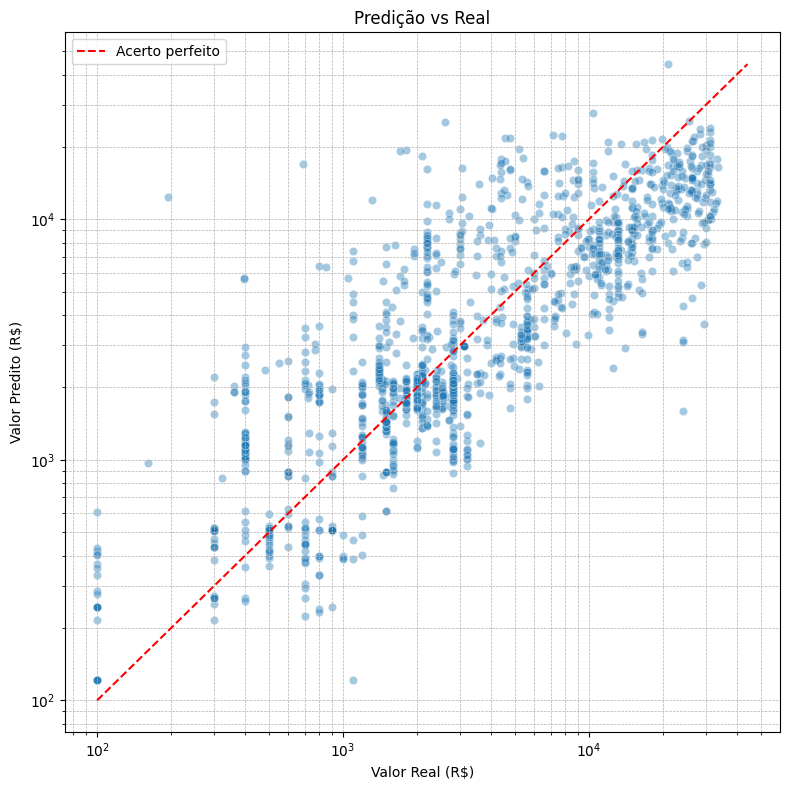

In [ ]:

# GRÁFICO — Predição vs Real
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_real, y=pred_real, alpha=0.4)

lims = [min(y_real.min(), pred_real.min()), max(y_real.max(), pred_real.max())]
plt.plot(lims, lims, 'r--', label='Acerto perfeito')

plt.xlabel("Valor Real (R$)")
plt.ylabel("Valor Predito (R$)")
plt.title("Predição vs Real")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

   decile  count           MAE          RMSE
0       0  152.0    676.800893   1400.834967
1       1  137.0   1019.328732   2021.761644
2       2  152.0   1122.755539   2607.182870
3       3  145.0    458.156825   1613.556807
4       4  208.0   1714.257075   3014.691502
5       5   61.0   2843.474336   3939.158339
6       6  142.0   3636.892368   5138.506220
7       7  144.0   4084.232648   4920.111863
8       8  141.0   5811.418717   6572.996096
9       9  143.0  13068.271030  14123.686059


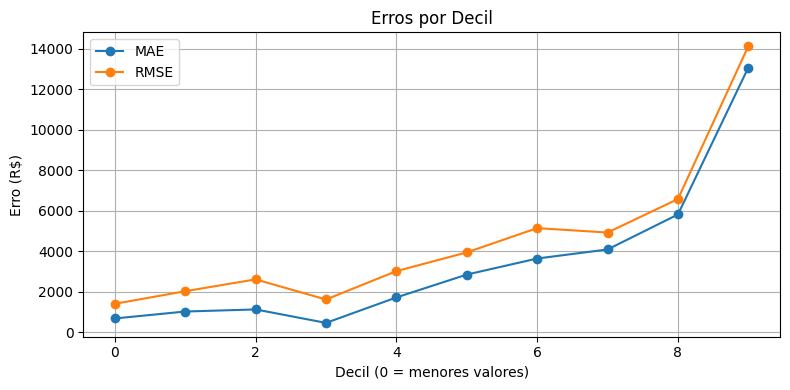

In [ ]:
# ERROS POR DECIL

df_errors = pd.DataFrame({'real': np.ravel(y_real), 'pred': np.ravel(pred_real)})
df_errors['decile'] = pd.qcut(df_errors['real'], 10, labels=False, duplicates='drop')

summary = df_errors.groupby('decile').apply(
    lambda g: pd.Series({
        'count': len(g),
        'MAE':  mean_absolute_error(g['real'], g['pred']),
        'RMSE': math.sqrt(mean_squared_error(g['real'], g['pred']))
    })
).reset_index()

print(summary)

plt.figure(figsize=(8, 4))
plt.plot(summary['decile'], summary['MAE'],  marker='o', label='MAE')
plt.plot(summary['decile'], summary['RMSE'], marker='o', label='RMSE')
plt.xlabel('Decil (0 = menores valores)')
plt.ylabel('Erro (R$)')
plt.title('Erros por Decil')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

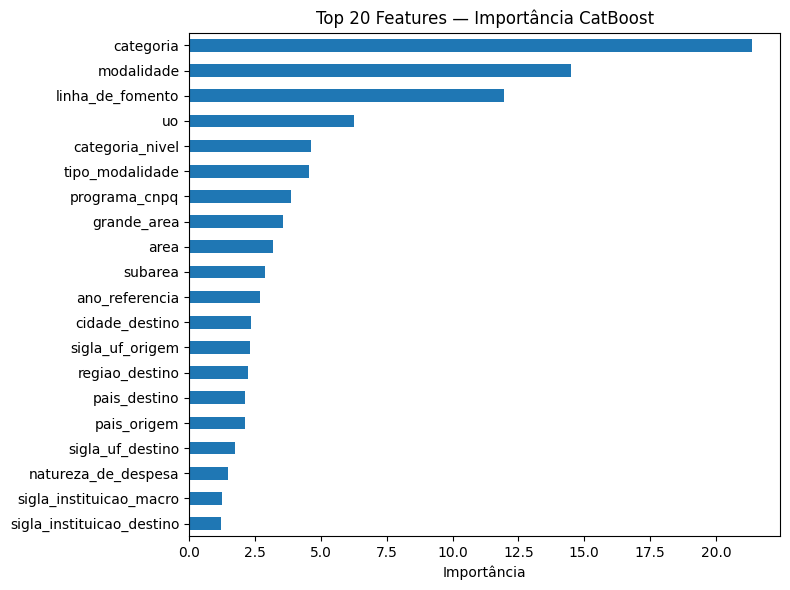

In [ ]:

# IMPORTÂNCIA DAS FEATURES

feat_imp = pd.Series(
    best_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(20).plot(kind='barh').invert_yaxis()
plt.title('Top 20 Features — Importância CatBoost')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

tipo_modalidade e categoria foram criados para resumir -> linha de fomento